In [1]:
# pip install attrs
# 注意不是 pip install attr
from chunking_evaluation import BaseChunker, GeneralEvaluation
from chromadb.utils import embedding_functions
import pandas as pd
import os

openai_api_key = os.environ.get("OPENAI_API_KEY")

Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1
Python-dotenv could not parse statement starting at line 1


------

In [3]:
from chunking_evaluation import SyntheticEvaluation

# Specify the corpora paths and output CSV file
corpora_paths = [
    'data/agile.txt',
    'data/finance.txt',
    'data/hbm.txt',
    'data/law.txt',
    'data/novel.txt',
]
queries_csv_path = 'generated_queries_excerpts.csv'

# Initialize the evaluation
evaluation = SyntheticEvaluation(corpora_paths, queries_csv_path, openai_api_key=openai_api_key)

In [17]:
evaluation.generate_queries_and_excerpts(num_rounds=3, queries_per_corpus=3)

Trying Query 0
Trying Query 1
Error occurred: No match found in the document for the given reference.
Reference: Keep a Solutions Log (紀錄下解決問題的辦法) 自己維護一份簡單的 solutions log 吧，紀錄下日期、問題描述、解法、參考網址等等資訊，之後碰到類似的問題就可以搜尋的到。將這份 log 用 wiki 維護也是不錯的主意。或是寫在 Blog 上，這樣 google 搞不好還會搜尋到自己以前寫的解法…XD
Trying Query 1
Trying Query 2
Error occurred: No match found in the document for the given reference.
Reference: agile 的精神不是告訴你設計、計畫不重要，缺少任何設計就進入 coding 是非常危險的。
Trying Query 2
Error occurred: No match found in the document for the given reference.
Reference: 一個內聚力不夠的軟體，當你要修改程式的時候就得多翻很多地方，每遇到某種變化，而要修改的程式碼散佈四處，不但難以找到，也很容易忘記。
Trying Query 2
Trying Query 0
Error occurred: No match found in the document for the given reference.
Reference: 在貨幣政策框架偏向寬鬆的設計下，我們認為今年剩下的三次FOMC會議皆可能降息，主因有二: 1)上週會議Powell明確表示聯準會不希望看到勞動市場進一步降溫，結果週五公布的就業報告顯示勞動市場降溫情況更顯著，且失業率已經高於官員對長期失業率的預估值(4.2%)；2)2019年在失業率3.6%的情況下，聯準會自7月起連續三次會議進行所謂的「預防性降息」，避免經濟受美中貿易戰影響而走弱。目前勞動市場情況顯然已弱於2019年當時，Powell理應更積極地降息，尤其尚須考量貨幣政策效果的滯後性。
Trying Query 0
Trying Query 1
Error

In [18]:
# Apply filter to remove queries with poor excerpts
evaluation.filter_poor_excerpts(threshold=0.36)

# Apply filter to remove duplicates
evaluation.filter_duplicates(threshold=0.6)

Corpus: data/agile.txt - Removed 3 .
Corpus: data/finance.txt - Removed 0 .
Corpus: data/hbm.txt - Removed 4 .
Corpus: data/law.txt - Removed 1 .
Corpus: data/novel.txt - Removed 5 .
Corpus: data/agile.txt - Removed 5 .
Corpus: data/finance.txt - Removed 8 .
Corpus: data/hbm.txt - Removed 4 .
Corpus: data/law.txt - Removed 5 .
Corpus: data/novel.txt - Removed 3 .


In [4]:
ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=openai_api_key,
    model_name="text-embedding-3-large")


In [ ]:
import requests
import json

class JinaChunker(BaseChunker):
    def __init__(self, chunk_size: int = 800):
        self._chunk_size = chunk_size

    def split_text(self, text):
        url = 'https://tokenize.jina.ai/'
        headers = {
            'Content-Type': 'application/json',
            'Authorization': 'Bearer jina_xxx'
        }
        payload = {
            'content': text,
            "tokenizer": "cl100k_base",
            'return_tokens': 'true',
            'return_chunks': 'true',
            'max_chunk_length': self._chunk_size
        }
        
        response = requests.post(url, headers=headers, data=json.dumps(payload))
        
        result = response.json()
        return result.get('chunks', [])



In [6]:
# 使用JinaChunker來示範文本分割

# 創建JinaChunker實例
jina_chunker = JinaChunker(chunk_size = 1000)

# 示例文本
demo_text = """
這是一個示範文本。它包含了多個句子。
我們將使用JinaChunker來分割這段文本。
這個分割器使用Jina AI的API來進行文本分割。
"""

# 使用JinaChunker分割文本
chunks = jina_chunker.split_text(demo_text)

# 打印分割結果
print("JinaChunker分割結果：")
for i, chunk in enumerate(chunks, 1):
    print(f"塊 {i}: {chunk}")

print(f"\n總共分割成 {len(chunks)} 個塊")


JinaChunker分割結果：
塊 1: 這是一個示範文本。它包含了多個句子。

塊 2: 我們將使用JinaChunker來分割這段文本。

塊 3: 這個分割器使用Jina AI的API來進行文本分割。


總共分割成 3 個塊


In [7]:
from chunking_evaluation.utils import openai_token_count
from chunking_evaluation.chunking import FixedTokenChunker, RecursiveTokenChunker, ClusterSemanticChunker, LLMSemanticChunker, KamradtModifiedChunker

my_separators = ["\n\n", "\n", ".", "?", "!", "\u200b", "\uff0c", "\u3001", "\uff0e", "\u3002", " ", ""]

chunkers = [
    JinaChunker(chunk_size=2000),    
    JinaChunker(chunk_size=1500),  
    JinaChunker(chunk_size=1000),  
    JinaChunker(chunk_size=800),  
    JinaChunker(chunk_size=600),  
    JinaChunker(chunk_size=400),  
    JinaChunker(chunk_size=200),
    RecursiveTokenChunker(chunk_size=2000, chunk_overlap=1000, length_function=openai_token_count, separators=my_separators),    
    RecursiveTokenChunker(chunk_size=1500, chunk_overlap=750, length_function=openai_token_count, separators=my_separators),    
    RecursiveTokenChunker(chunk_size=1000, chunk_overlap=500, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=800, chunk_overlap=400, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=600, chunk_overlap=300, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=400, chunk_overlap=200, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=200, chunk_overlap=100, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=2000, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=1500, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=1000, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=800, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=600, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=400, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=200, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    KamradtModifiedChunker(avg_chunk_size = 2000, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 1500, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 1000, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 800, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 600, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 400, embedding_function = ef),
    KamradtModifiedChunker(avg_chunk_size = 200, embedding_function = ef),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=2000, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=1500, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=1000, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=800, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=600, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=400, length_function=openai_token_count),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=200, length_function=openai_token_count),
    LLMSemanticChunker(organisation="openai", model_name="gpt-4o-mini", api_key=openai_api_key),
    LLMSemanticChunker(organisation="openai", model_name="gpt-4o-2024-08-06", api_key=openai_api_key)
]

In [8]:
results = []
df = pd.DataFrame()

for chunker in chunkers:
    result = evaluation.run(chunker, ef, retrieve=5)
    del result['corpora_scores']  # Remove detailed scores for brevity
    chunk_size = chunker._chunk_size if hasattr(chunker, '_chunk_size') else 0
    chunk_overlap = chunker._chunk_overlap if hasattr(chunker, '_chunk_overlap') else 0
    result['chunker'] = chunker.__class__.__name__ + f"_{chunk_size}_{chunk_overlap}"
    result['retrieve'] = 5
    results.append(result)

    # Update the DataFrame
    df = pd.DataFrame(results)    

Processing chunks: 100%|██████████| 729/729 [00:28<00:00, 25.19it/s]


In [9]:
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker,retrieve
0,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_2000_0,5
1,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1500_0,5
2,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1000_0,5
3,0.266807,0.185029,0.755989,0.325661,0.663054,0.206735,0.285727,0.187926,JinaChunker_800_0,5
4,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_600_0,5
5,0.266452,0.185855,0.756536,0.330842,0.663054,0.206735,0.284592,0.188305,JinaChunker_400_0,5
6,0.268275,0.184448,0.761060,0.325473,0.663054,0.206735,0.287022,0.187351,JinaChunker_200_0,5
7,0.024306,0.019566,0.872698,0.317758,0.094832,0.089678,0.024312,0.019562,RecursiveTokenChunker_2000_1000,5
8,0.032729,0.023091,0.915414,0.243197,0.115889,0.092872,0.032755,0.023086,RecursiveTokenChunker_1500_750,5
9,0.048299,0.031638,0.953899,0.167574,0.153778,0.106984,0.048355,0.031661,RecursiveTokenChunker_1000_500,5


In [10]:
chunkers2 = [
    JinaChunker(chunk_size=400),  
    RecursiveTokenChunker(chunk_size=400, chunk_overlap=200, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=400, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    KamradtModifiedChunker(avg_chunk_size = 400, embedding_function = ef),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=400, length_function=openai_token_count),
]

In [11]:
for chunker in chunkers2:
    result = evaluation.run(chunker, ef, retrieve=10)
    del result['corpora_scores']  # Remove detailed scores for brevity
    chunk_size = chunker._chunk_size if hasattr(chunker, '_chunk_size') else 0
    chunk_overlap = chunker._chunk_overlap if hasattr(chunker, '_chunk_overlap') else 0
    result['chunker'] = chunker.__class__.__name__ + f"_{chunk_size}_{chunk_overlap}_n_10"
    result['retrieve'] = 10
    results.append(result)

    # Update the DataFrame
    df = pd.DataFrame(results)    

In [12]:
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker,retrieve
0,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_2000_0,5
1,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1500_0,5
2,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1000_0,5
3,0.266807,0.185029,0.755989,0.325661,0.663054,0.206735,0.285727,0.187926,JinaChunker_800_0,5
4,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_600_0,5
5,0.266452,0.185855,0.756536,0.330842,0.663054,0.206735,0.284592,0.188305,JinaChunker_400_0,5
6,0.268275,0.184448,0.761060,0.325473,0.663054,0.206735,0.287022,0.187351,JinaChunker_200_0,5
7,0.024306,0.019566,0.872698,0.317758,0.094832,0.089678,0.024312,0.019562,RecursiveTokenChunker_2000_1000,5
8,0.032729,0.023091,0.915414,0.243197,0.115889,0.092872,0.032755,0.023086,RecursiveTokenChunker_1500_750,5
9,0.048299,0.031638,0.953899,0.167574,0.153778,0.106984,0.048355,0.031661,RecursiveTokenChunker_1000_500,5


In [13]:
chunkers3 = [
    JinaChunker(chunk_size=200), 
    RecursiveTokenChunker(chunk_size=200, chunk_overlap=100, length_function=openai_token_count, separators=my_separators),
    RecursiveTokenChunker(chunk_size=200, chunk_overlap=0, length_function=openai_token_count, separators=my_separators),
    KamradtModifiedChunker(avg_chunk_size = 200, embedding_function = ef),
    ClusterSemanticChunker(embedding_function=ef, max_chunk_size=200, length_function=openai_token_count),
]

for chunker in chunkers3:
    result = evaluation.run(chunker, ef, retrieve=20)
    del result['corpora_scores']  # Remove detailed scores for brevity
    chunk_size = chunker._chunk_size if hasattr(chunker, '_chunk_size') else 0
    chunk_overlap = chunker._chunk_overlap if hasattr(chunker, '_chunk_overlap') else 0
    result['chunker'] = chunker.__class__.__name__ + f"_{chunk_size}_{chunk_overlap}_n_20"
    result['retrieve'] = 20
    results.append(result)

    # Update the DataFrame
    df = pd.DataFrame(results)    

In [14]:
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker,retrieve
0,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_2000_0,5
1,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1500_0,5
2,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1000_0,5
3,0.266807,0.185029,0.755989,0.325661,0.663054,0.206735,0.285727,0.187926,JinaChunker_800_0,5
4,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_600_0,5
5,0.266452,0.185855,0.756536,0.330842,0.663054,0.206735,0.284592,0.188305,JinaChunker_400_0,5
6,0.268275,0.184448,0.761060,0.325473,0.663054,0.206735,0.287022,0.187351,JinaChunker_200_0,5
7,0.024306,0.019566,0.872698,0.317758,0.094832,0.089678,0.024312,0.019562,RecursiveTokenChunker_2000_1000,5
8,0.032729,0.023091,0.915414,0.243197,0.115889,0.092872,0.032755,0.023086,RecursiveTokenChunker_1500_750,5
9,0.048299,0.031638,0.953899,0.167574,0.153778,0.106984,0.048355,0.031661,RecursiveTokenChunker_1000_500,5


In [15]:
df.at[21, 'chunker'] = 'KamradtModifiedChunker_2000'
df.at[22, 'chunker'] = 'KamradtModifiedChunker_1500'
df.at[23, 'chunker'] = 'KamradtModifiedChunker_1000'
df.at[24, 'chunker'] = 'KamradtModifiedChunker_800'
df.at[25, 'chunker'] = 'KamradtModifiedChunker_600'
df.at[26, 'chunker'] = 'KamradtModifiedChunker_400'
df.at[27, 'chunker'] = 'KamradtModifiedChunker_200'
df.at[35, 'chunker'] = 'LLMSemanticChunker_gpt-4o-mini'
df.at[36, 'chunker'] = 'LLMSemanticChunker_gpt-4o'
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker,retrieve
0,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_2000_0,5
1,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1500_0,5
2,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_1000_0,5
3,0.266807,0.185029,0.755989,0.325661,0.663054,0.206735,0.285727,0.187926,JinaChunker_800_0,5
4,0.268229,0.184468,0.761060,0.325473,0.663054,0.206735,0.286976,0.187375,JinaChunker_600_0,5
5,0.266452,0.185855,0.756536,0.330842,0.663054,0.206735,0.284592,0.188305,JinaChunker_400_0,5
6,0.268275,0.184448,0.761060,0.325473,0.663054,0.206735,0.287022,0.187351,JinaChunker_200_0,5
7,0.024306,0.019566,0.872698,0.317758,0.094832,0.089678,0.024312,0.019562,RecursiveTokenChunker_2000_1000,5
8,0.032729,0.023091,0.915414,0.243197,0.115889,0.092872,0.032755,0.023086,RecursiveTokenChunker_1500_750,5
9,0.048299,0.031638,0.953899,0.167574,0.153778,0.106984,0.048355,0.031661,RecursiveTokenChunker_1000_500,5


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

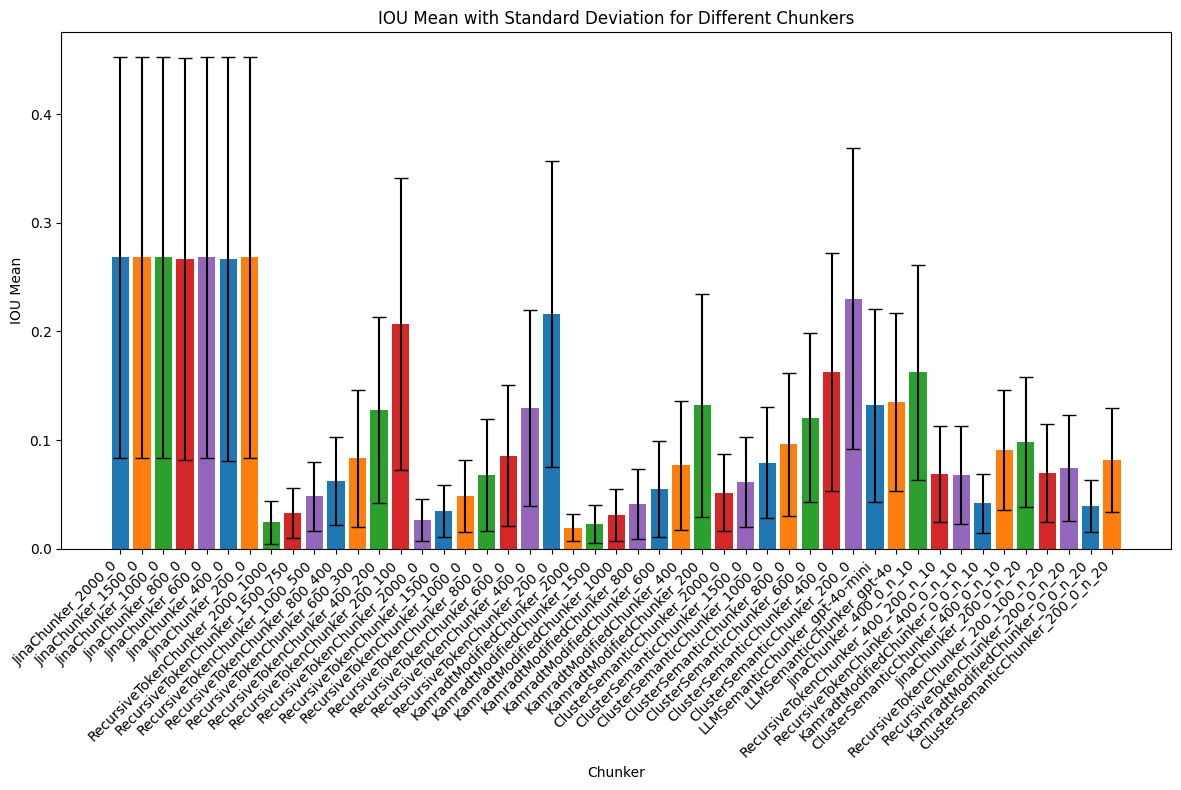

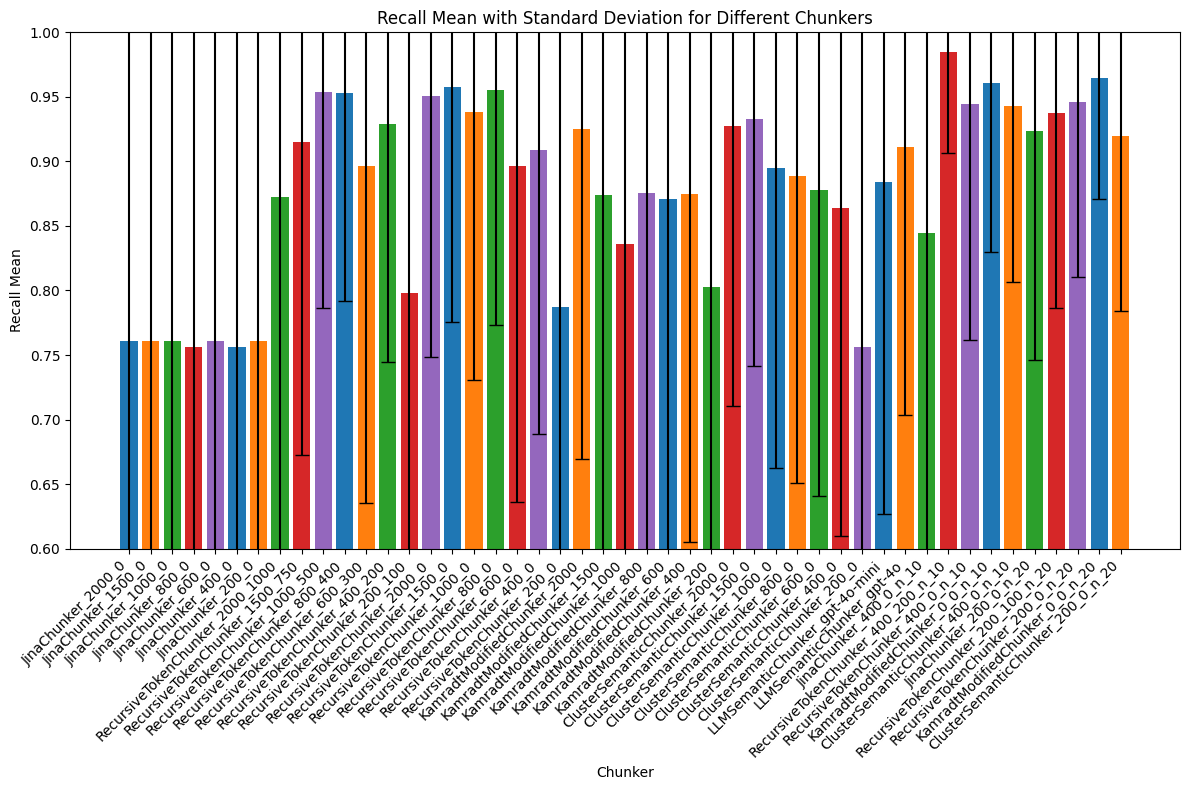

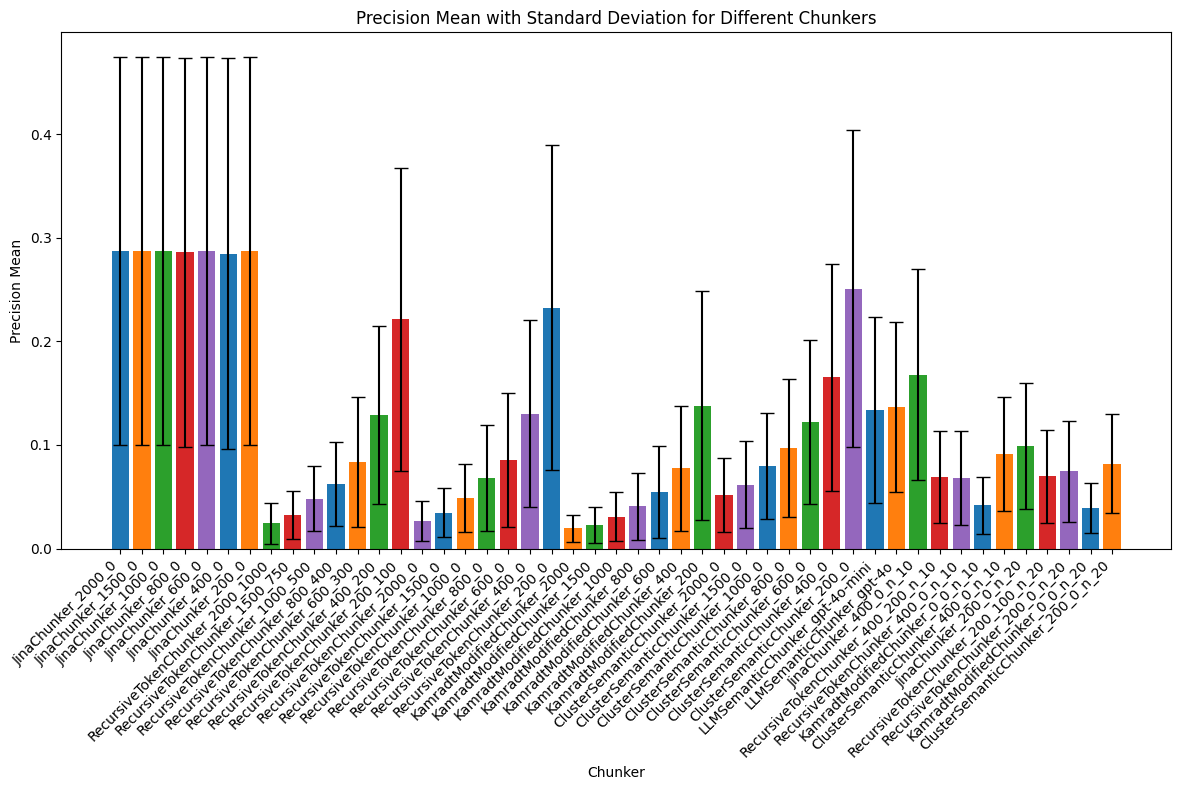

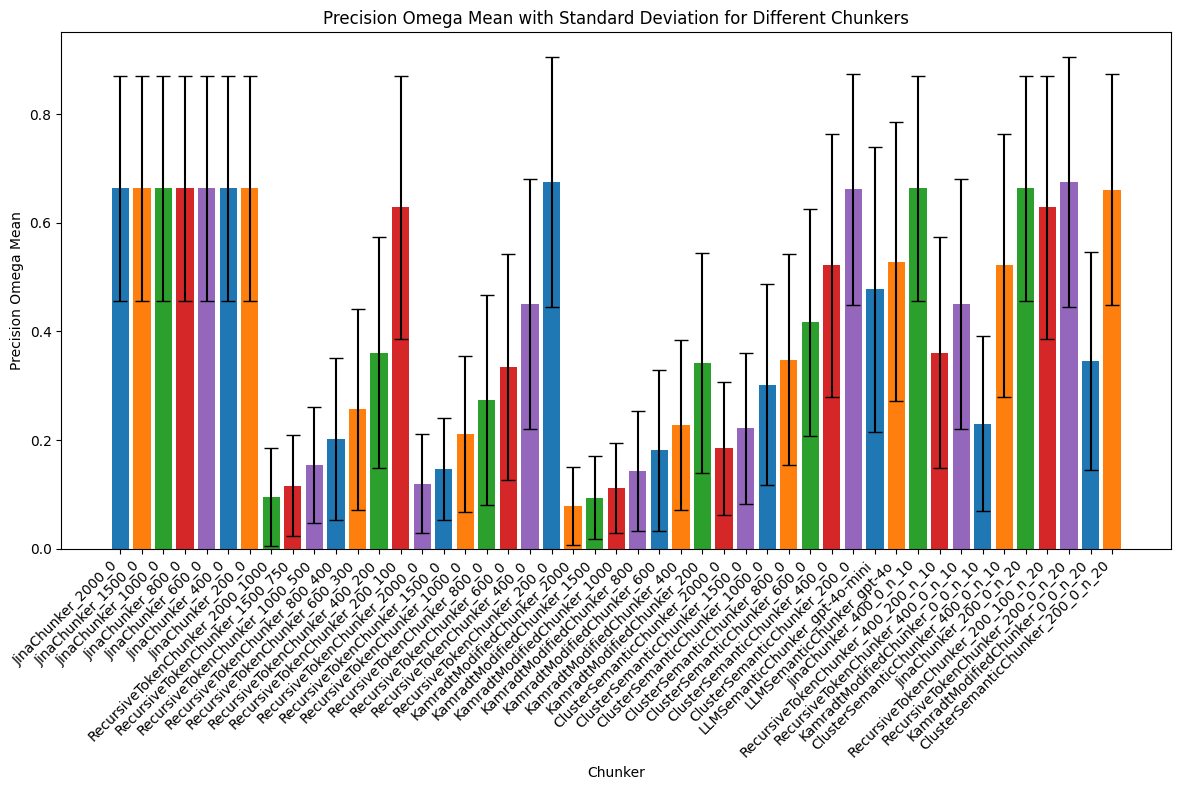

In [17]:
# 設定顏色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# IOU Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['iou_mean'], yerr=df['iou_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('IOU Mean')
plt.title('IOU Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()

# Recall Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['recall_mean'], yerr=df['recall_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Recall Mean')
plt.title('Recall Mean with Standard Deviation for Different Chunkers')
plt.ylim(0.6, 1)
plt.tight_layout()
plt.show()

# Precision Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['precision_mean'], yerr=df['precision_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Precision Mean')
plt.title('Precision Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()

# Precision Omega Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['precision_omega_mean'], yerr=df['precision_omega_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Precision Omega Mean')
plt.title('Precision Omega Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()

----- 以下是 v1

In [19]:
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker
0,0.024303,0.019565,0.872698,0.317758,0.094832,0.089678,0.024309,0.019561,RecursiveTokenChunker_2000_1000
1,0.032733,0.022666,0.925414,0.225247,0.115889,0.092872,0.032760,0.022661,RecursiveTokenChunker_1500_750
2,0.048256,0.031613,0.953899,0.167574,0.153778,0.106984,0.048313,0.031636,RecursiveTokenChunker_1000_500
3,0.061952,0.040394,0.952757,0.161036,0.201737,0.148911,0.062119,0.040410,RecursiveTokenChunker_800_400
4,0.083118,0.063006,0.896575,0.260894,0.256666,0.184655,0.083460,0.062941,RecursiveTokenChunker_600_300
5,0.128779,0.086951,0.932215,0.183282,0.360697,0.212270,0.129888,0.087239,RecursiveTokenChunker_400_200
6,0.199555,0.128156,0.784663,0.305844,0.633971,0.239895,0.214304,0.140904,RecursiveTokenChunker_200_100
7,0.026458,0.019269,0.950351,0.201714,0.119628,0.090725,0.026463,0.019269,RecursiveTokenChunker_2000_0
8,0.034873,0.024285,0.957486,0.181693,0.147295,0.093922,0.034885,0.024284,RecursiveTokenChunker_1500_0
9,0.048214,0.033541,0.928155,0.227480,0.211154,0.142809,0.048289,0.033531,RecursiveTokenChunker_1000_0


In [23]:
df.at[14, 'chunker'] = 'KamradtModifiedChunker_2000'
df.at[15, 'chunker'] = 'KamradtModifiedChunker_1500'
df.at[16, 'chunker'] = 'KamradtModifiedChunker_1000'
df.at[17, 'chunker'] = 'KamradtModifiedChunker_800'
df.at[18, 'chunker'] = 'KamradtModifiedChunker_600'
df.at[19, 'chunker'] = 'KamradtModifiedChunker_400'
df.at[20, 'chunker'] = 'KamradtModifiedChunker_200'
df.at[28, 'chunker'] = 'LLMSemanticChunker_gpt-4o-mini'
df.at[29, 'chunker'] = 'LLMSemanticChunker_gpt-4o'
df

,iou_mean,iou_std,recall_mean,recall_std,precision_omega_mean,precision_omega_std,precision_mean,precision_std,chunker
0,0.024303,0.019565,0.872698,0.317758,0.094832,0.089678,0.024309,0.019561,RecursiveTokenChunker_2000_1000
1,0.032733,0.022666,0.925414,0.225247,0.115889,0.092872,0.032760,0.022661,RecursiveTokenChunker_1500_750
2,0.048256,0.031613,0.953899,0.167574,0.153778,0.106984,0.048313,0.031636,RecursiveTokenChunker_1000_500
3,0.061952,0.040394,0.952757,0.161036,0.201737,0.148911,0.062119,0.040410,RecursiveTokenChunker_800_400
4,0.083118,0.063006,0.896575,0.260894,0.256666,0.184655,0.083460,0.062941,RecursiveTokenChunker_600_300
5,0.128779,0.086951,0.932215,0.183282,0.360697,0.212270,0.129888,0.087239,RecursiveTokenChunker_400_200
6,0.199555,0.128156,0.784663,0.305844,0.633971,0.239895,0.214304,0.140904,RecursiveTokenChunker_200_100
7,0.026458,0.019269,0.950351,0.201714,0.119628,0.090725,0.026463,0.019269,RecursiveTokenChunker_2000_0
8,0.034873,0.024285,0.957486,0.181693,0.147295,0.093922,0.034885,0.024284,RecursiveTokenChunker_1500_0
9,0.048214,0.033541,0.928155,0.227480,0.211154,0.142809,0.048289,0.033531,RecursiveTokenChunker_1000_0


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

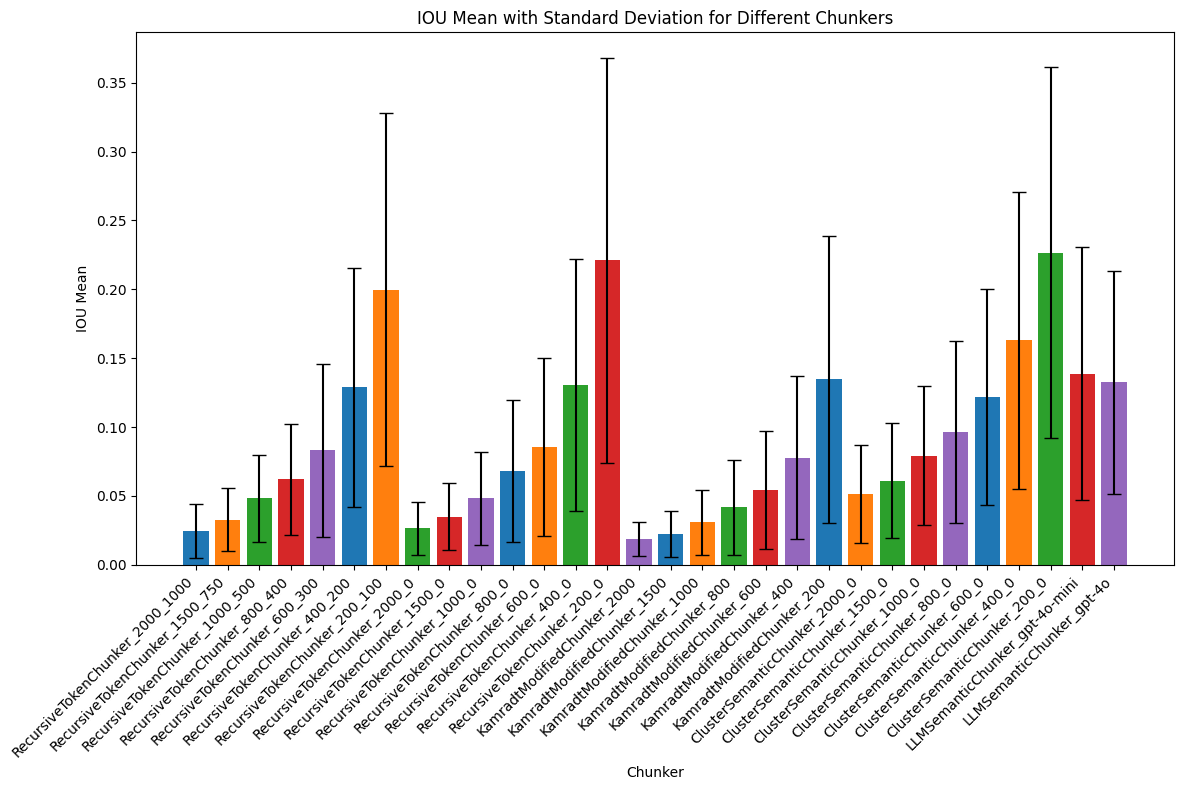

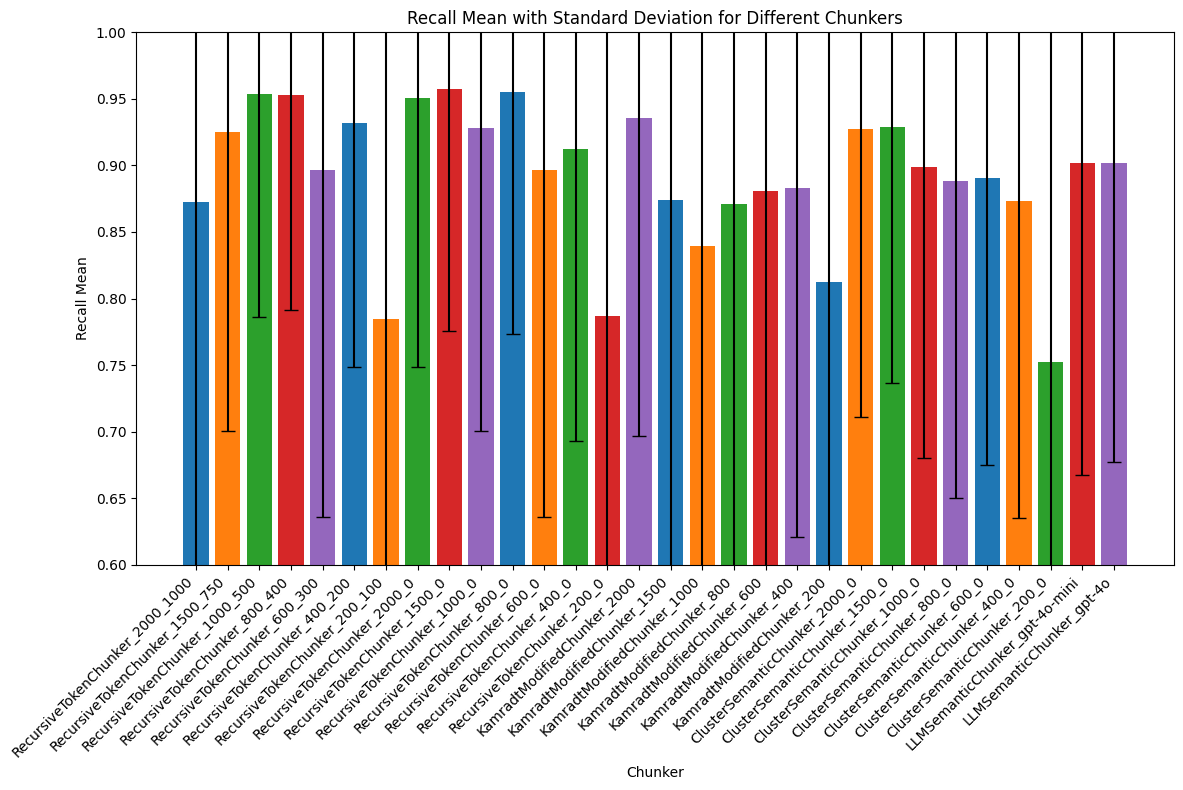

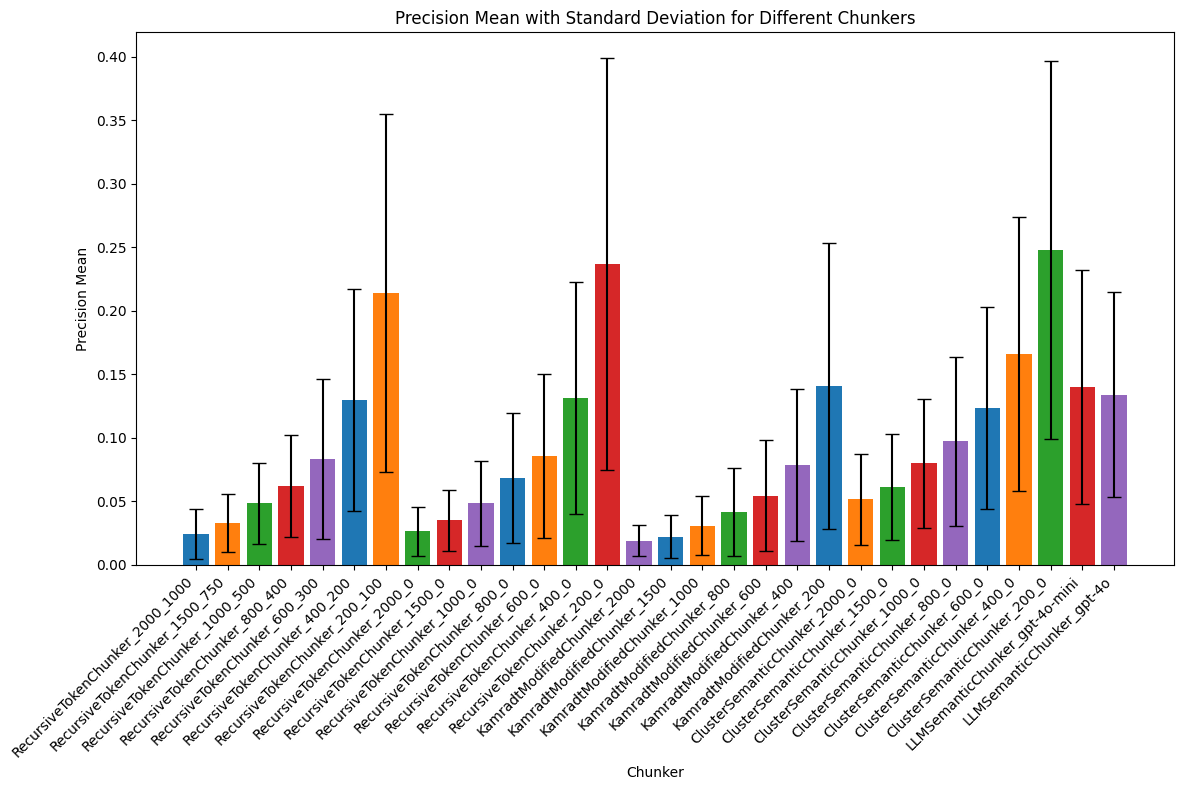

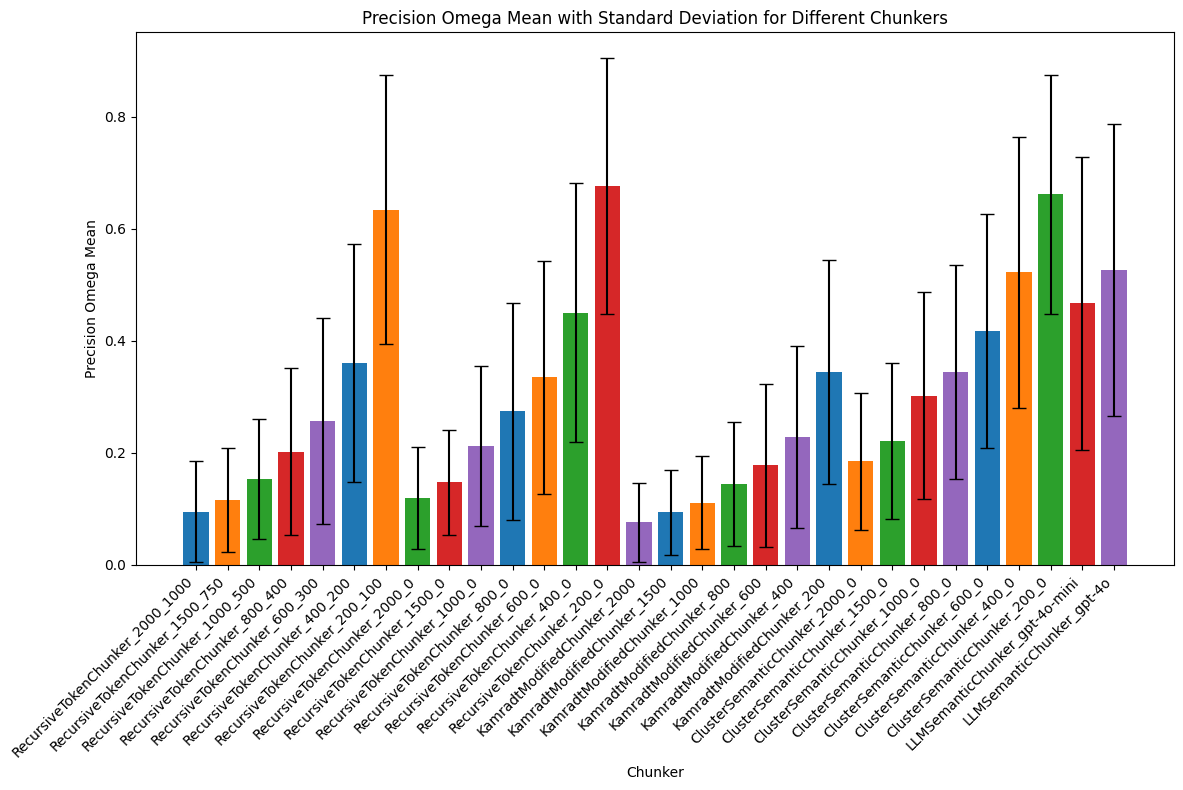

In [24]:
# 設定顏色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# IOU Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['iou_mean'], yerr=df['iou_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('IOU Mean')
plt.title('IOU Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()

# Recall Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['recall_mean'], yerr=df['recall_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Recall Mean')
plt.title('Recall Mean with Standard Deviation for Different Chunkers')
plt.ylim(0.6, 1)
plt.tight_layout()
plt.show()

# Precision Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['precision_mean'], yerr=df['precision_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Precision Mean')
plt.title('Precision Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()

# Precision Omega Mean with Standard Deviation
plt.figure(figsize=(12, 8))
plt.bar(df['chunker'], df['precision_omega_mean'], yerr=df['precision_omega_std'], color=colors, capsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Chunker')
plt.ylabel('Precision Omega Mean')
plt.title('Precision Omega Mean with Standard Deviation for Different Chunkers')
plt.tight_layout()
plt.show()